In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# load $D_{\ell}^{TT}$ samples for set of cosmological parameters 

In [2]:
data_path=Path('../data/')
training_features_1 = np.load(str(data_path /'./camb_TT_training_log_spectra_1.npz'))

TT = training_features_1['features'] #np.load("../data/TT_training.npy")
Nsample, lmax = TT.shape
#TT = np.log(TT)
print(f"This is a set of {Nsample}  samples for lmax = {lmax} of log(TT) ")

This is a set of 15000  samples for lmax = 2507 of log(TT) 


In [3]:
def compute_PCA(TT, k=None,coeff=None,inverse=False):
    # Mean spectrum
    mean_TT = np.mean(TT, axis=0)
    Nsample, Nell = TT.shape
    # Center the data around mean
    X = TT - mean_TT
    # covariance
    Cov = X.T @ X / (Nsample-1)
    # Eigen value - decomposition
    eigvals, eigvecs = np.linalg.eigh(Cov)
    idx = np.argsort(eigvals)[::-1]

    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx]
    # Keep first k principal components
    W = eigvecs[:,:k]
    
    
    

    # ---------- Inverse PCA ----------
    if inverse:
        
        X_rec = coeff @ W.T
        TT_rec = X_rec + mean_TT
        return(TT_rec)
     # ---------- Forward PCA ----------
    else:
       
        coeff = X @ W
        return(coeff)

# Compute the first 20 PCA coefficients from $\log10(C_{\ell})$

In [4]:
coeff = compute_PCA(TT, k=20)
coeff.shape

(15000, 20)

# Inverse transfromation to get $\log10(C_{\ell})$ using precomputed PCA coefficients

In [6]:
TT_rec = compute_PCA(TT, k=20,coeff=coeff,inverse=True)
TT_rec = 10**(TT_rec)

# Compare the original and PCA generated TT power spectrum

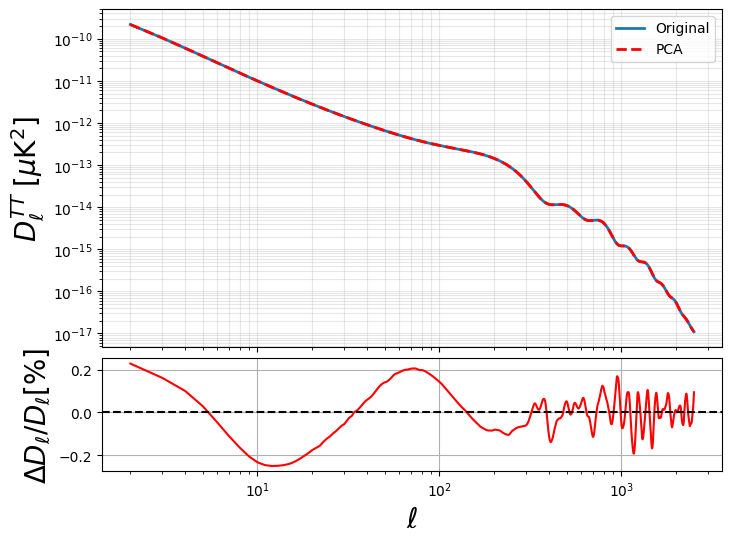

In [8]:
TT_true = 10**(TT)
ells = np.arange(2, lmax+2)

i = 100

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8,6),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1], 'hspace':0.05}
)

#---------------------------------------
# Upper panel
#---------------------------------------

ax1.loglog(ells, TT_true[i], lw=2, label='Original')
ax1.loglog(ells, TT_rec[i], '--', lw=2, label='PCA',color='r')

ax1.set_ylabel(r'$D_\ell^{TT}\;[\mu{\rm K}^2]$',fontsize=20)
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

#---------------------------------------
# Lower panel
#---------------------------------------

frac = (TT_rec[i]-TT_true[i])*100/TT_true[i]

ax2.plot(ells, frac, 'r')

ax2.axhline(0, color='k', ls='--')

ax2.set_xlabel(r'$\ell$',fontsize=20)
ax2.set_ylabel(r'$\Delta D_{\ell}/D_{\ell} [\%]$',fontsize=20)

ax2.grid(True)

plt.show()

# Repeat the same tasks using sklearn functions

In [29]:
from sklearn.decomposition import PCA, IncrementalPCA
TT = training_features_1['features']
Nsample, lmax = TT.shape
#TT = np.log(TT)
print(f"This is a set of {Nsample}  samples for lmax = {lmax} of log(TT) ")
n_pca=40
#pca = PCA(n_components=n_pca)
pca=IncrementalPCA(n_components=n_pca)

coeff_ = pca.fit_transform(TT)
coeff_.shape

This is a set of 15000  samples for lmax = 2507 of log(TT) 


(15000, 40)

In [39]:
TT_rec_ = pca.inverse_transform(coeff_)

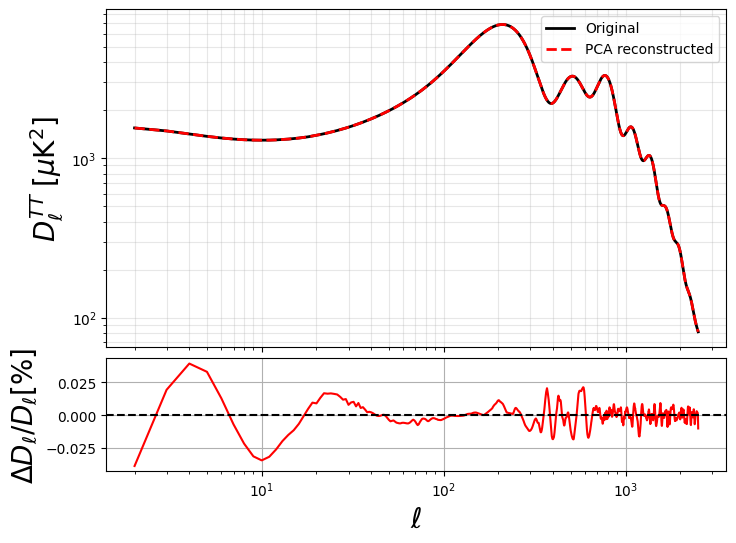

In [43]:
TT_rec__ = 10**(TT_rec_)

TT_true_ = 10**(TT)

ells = np.arange(2, lmax+2)

i = 100

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8,6),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1], 'hspace':0.05}
)

#---------------------------------------
# Upper panel
#---------------------------------------
factor=((2.7255e6)**2)*ells*(ells+1)/(2*np.pi)
ax1.loglog(ells, factor*TT_true_[i], lw=2, color='k',label='Original')
ax1.loglog(ells, factor*TT_rec__[i], '--', lw=2, label='PCA reconstructed',color='r')

ax1.set_ylabel(r'$D_\ell^{TT}\;[\mu{\rm K}^2]$',fontsize=20)
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

#---------------------------------------
# Lower panel
#---------------------------------------

frac = (TT_rec__[i]-TT_true_[i])*100/TT_true_[i]

ax2.plot(ells, frac, 'r')

ax2.axhline(0, color='k', ls='--')

ax2.set_xlabel(r'$\ell$',fontsize=20)
ax2.set_ylabel(r'$\Delta D_{\ell}/D_{\ell} [\%]$',fontsize=20)

ax2.grid(True)

plt.show()

# Tutorial 1
Investigate how the reconstruction error changes with the number of PCA coefficients.


pcs = [2,5,10,20,30,50,100]

errors = []

for n_pc in pcs:

    pca = PCA(n_components=n_pc)

    coeff = pca.fit_transform(TT)

    TT_rec = pca.inverse_transform(coeff)

    TT_rec = 10**(TT_rec)

    err = np.mean(np.abs((TT_rec-10**(TT))*100/np.exp(TT)))

    errors.append(err)

Plot the mean changes

In [26]:
"""
plt.figure(figsize=(6,4))

plt.semilogy(pcs,errors,'o-')

plt.xlabel("Number of PCA components")

plt.ylabel("Mean fractional error")

plt.grid(True)

plt.show()
"""

'\nplt.figure(figsize=(6,4))\n\nplt.semilogy(pcs,errors,\'o-\')\n\nplt.xlabel("Number of PCA components")\n\nplt.ylabel("Mean fractional error")\n\nplt.grid(True)\n\nplt.show()\n'